In [83]:
import pandas as pd
import numpy as np

features = pd.read_csv("hotels-europe_features.csv")
price = pd.read_csv("hotels-europe_price.csv")

df_full = pd.merge(features, price, on="hotel_id")
df_full = df_full.sort_values(["hotel_id", "year", "month"]).copy()

sequence_length = 3

tabular_cols = [
    "distance", "stars", "rating", "rating_reviewcount",
    "ratingta", "ratingta_count", "distance_alter",
    "city", "accommodation_type", "offer", "offer_cat",
    "year", "month", "weekend", "holiday", "nnights", "scarce_room"
]

rows = []

for hotel_id, group in df_full.groupby("hotel_id"):
    group = group.sort_values(["year", "month"]).reset_index(drop=True)

    if len(group) <= sequence_length:
        continue

    for i in range(len(group) - sequence_length):
        hist_prices = group.loc[i:i+sequence_length-1, "price"].values
        target_row = group.loc[i+sequence_length]

        row = {
            "hotel_id": hotel_id,
            "target_price": target_row["price"]
        }

        for j in range(sequence_length):
            row[f"hist_price_{j+1}"] = hist_prices[j]

        for col in tabular_cols:
            row[col] = target_row[col]

        rows.append(row)

aligned_df = pd.DataFrame(rows)

print(aligned_df.shape)
print(aligned_df.head())

(85788, 22)
   hotel_id  target_price  hist_price_1  hist_price_2  hist_price_3  distance  \
0         1           552           172           114           122       3.1   
1         1           122           114           122           552       3.1   
2         1           122           122           552           122       3.1   
3         3           737           217           117           118       1.5   
4         3           114           117           118           737       1.5   

   stars  rating  rating_reviewcount  ratingta  ...       city  \
0    4.0     4.3              1030.0       4.0  ...  Amsterdam   
1    4.0     4.3              1030.0       4.0  ...  Amsterdam   
2    4.0     4.3              1030.0       4.0  ...  Amsterdam   
3    4.0     4.1               165.0       4.0  ...  Amsterdam   
4    4.0     4.1               165.0       4.0  ...  Amsterdam   

   accommodation_type offer     offer_cat  year month  weekend  holiday  \
0               Hotel     1  

In [84]:
# ===== LSTM data from aligned_df =====
X_seq = aligned_df[[f"hist_price_{i+1}" for i in range(sequence_length)]].values
y_seq = aligned_df["target_price"].values

# reshape to (samples, time_steps, features)
X_seq = X_seq.reshape(X_seq.shape[0], X_seq.shape[1], 1)

print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)

X_seq shape: (85788, 3, 1)
y_seq shape: (85788,)


In [85]:
X_train_seq = X_seq[train_idx]
X_test_seq = X_seq[test_idx]
y_train_seq = y_seq[train_idx]
y_test_seq = y_seq[test_idx]

print("X_train_seq shape:", X_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)
print("X_test_seq shape:", X_test_seq.shape)
print("y_test_seq shape:", y_test_seq.shape)

X_train_seq shape: (68630, 3, 1)
y_train_seq shape: (68630,)
X_test_seq shape: (17158, 3, 1)
y_test_seq shape: (17158,)


In [86]:
#Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

model_lr = LinearRegression()
model_lr.fit(X_train_tab, y_train_tab)

pred_lr = model_lr.predict(X_test_tab)

rmse_lr = np.sqrt(mean_squared_error(y_test_tab, pred_lr))
mae_lr = mean_absolute_error(y_test_tab, pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression MAE:", mae_lr)

Linear Regression RMSE: 326.6620935295744
Linear Regression MAE: 64.97788293443813


In [87]:
#MLP
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

scaler_tab = StandardScaler()
X_train_tab_scaled = scaler_tab.fit_transform(X_train_tab)
X_test_tab_scaled = scaler_tab.transform(X_test_tab)

model_mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    max_iter=300,
    random_state=42
)

model_mlp.fit(X_train_tab_scaled, y_train_tab)

pred_mlp = model_mlp.predict(X_test_tab_scaled)

rmse_mlp = np.sqrt(mean_squared_error(y_test_tab, pred_mlp))
mae_mlp = mean_absolute_error(y_test_tab, pred_mlp)

print("MLP RMSE:", rmse_mlp)
print("MLP MAE:", mae_mlp)

MLP RMSE: 321.5821147319923
MLP MAE: 51.877262520520325


D:\ProgramData\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:614: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [88]:
#LSTM
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping


scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_seq_scaled = scaler_x.fit_transform(X_seq.reshape(-1, 1)).reshape(X_seq.shape[0], X_seq.shape[1], 1)
y_seq_scaled = scaler_y.fit_transform(y_seq.reshape(-1, 1)).flatten()

print("Scaled X_seq shape:", X_seq_scaled.shape)
print("Scaled y_seq shape:", y_seq_scaled.shape)

indices = np.arange(len(aligned_df))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42
)

X_train_seq = X_seq_scaled[train_idx]
X_test_seq = X_seq_scaled[test_idx]
y_train_seq = y_seq_scaled[train_idx]
y_test_seq = y_seq_scaled[test_idx]

print("X_train_seq:", X_train_seq.shape)
print("y_train_seq:", y_train_seq.shape)
print("X_test_seq:", X_test_seq.shape)
print("y_test_seq:", y_test_seq.shape)


model_lstm = Sequential([
    LSTM(64, input_shape=(sequence_length, 1)),
    Dense(32, activation="relu"),
    Dense(1)
])

model_lstm.compile(
    optimizer="adam",
    loss="mse"
)

model_lstm.summary()

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model_lstm.fit(
    X_train_seq,
    y_train_seq,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


pred_lstm_scaled = model_lstm.predict(X_test_seq).flatten()

pred_lstm = scaler_y.inverse_transform(pred_lstm_scaled.reshape(-1, 1)).flatten()
y_test_real = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

rmse_lstm = np.sqrt(mean_squared_error(y_test_real, pred_lstm))
mae_lstm = mean_absolute_error(y_test_real, pred_lstm)

print("LSTM RMSE:", rmse_lstm)
print("LSTM MAE:", mae_lstm)

Scaled X_seq shape: (85788, 3, 1)
Scaled y_seq shape: (85788,)
X_train_seq: (68630, 3, 1)
y_train_seq: (68630,)
X_test_seq: (17158, 3, 1)
y_test_seq: (17158,)


D:\ProgramData\Anaconda3\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                        │ (None, 64)                  │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1716/1716 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 1.9834e-05 - val_loss: 1.6328e-05
Epoch 2/20
1716/1716 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 1.8711e-05 - val_loss: 1.6133e-05
Epoch 3/20
1716/1716 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 1.7540e-05 - val_loss: 1.8024e-05
Epoch 4/20
1716/1716 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 1.8585e-05 - val_loss: 1.5929e-05
Epoch 5/20
1716/1716 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 1.8558e-05 - val_loss: 1.6365e-05
Epoch 6/20
1716/1716 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 1.7875e-05 - val_loss: 1.6725e-05
Epoch 7/20
1716/1716 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 1.6136e-05 - val_loss: 1.6310e-05
537/537 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
LSTM RMSE: 340.94314513127165
LSTM MAE: 82.28638231966904


In [89]:
from tensorflow.keras.layers import Input, Dense, LSTM, Concatenate
from tensorflow.keras.models import Model
from sklearn.metrics import mean_squared_error, mean_absolute_error

# tabular branch
input_tab = Input(shape=(X_train_tab_scaled.shape[1],))
x_tab = Dense(64, activation="relu")(input_tab)
x_tab = Dense(32, activation="relu")(x_tab)

# sequence branch
input_seq = Input(shape=(sequence_length, 1))
x_seq = LSTM(32)(input_seq)

# fusion
combined = Concatenate()([x_tab, x_seq])
x = Dense(32, activation="relu")(combined)
output = Dense(1)(x)

model_fusion = Model(inputs=[input_tab, input_seq], outputs=output)
model_fusion.compile(optimizer="adam", loss="mse")

model_fusion.fit(
    [X_train_tab_scaled, X_train_seq],
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

pred_fusion = model_fusion.predict([X_test_tab_scaled, X_test_seq]).flatten()

rmse_mm_tab_time = np.sqrt(mean_squared_error(y_test, pred_fusion))
mae_mm_tab_time = mean_absolute_error(y_test, pred_fusion)

print("Fusion RMSE:", rmse_mm_tab_time)
print("Fusion MAE:", mae_mm_tab_time)

Epoch 1/10
1716/1716 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 25784.5430 - val_loss: 16904.5820
Epoch 2/10
1716/1716 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 21725.5234 - val_loss: 16474.6348
Epoch 3/10
1716/1716 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 23878.2188 - val_loss: 14971.1309
Epoch 4/10
1716/1716 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 18410.4375 - val_loss: 14952.8828
Epoch 5/10
1716/1716 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 18252.0840 - val_loss: 13327.1768
Epoch 6/10
1716/1716 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 21280.7832 - val_loss: 12839.7529
Epoch 7/10
1716/1716 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 14791.5713 - val_loss: 12802.3477
Epoch 8/10
1716/1716 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 11893.8643 - val_loss: 12154.0713
Epoch 9/10
1716/1716 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 11460.9492 - val_loss: 12008.2217
Epoch 10/10
1716/1716 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 11612.7256 - val_loss: 12138.7490
537/537 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/st

In [90]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "MLP",
        "LSTM",
        "MM(MLP+LSTM)"
    ],
    "RMSE": [
        rmse_lr,
        rmse_mlp,
        rmse_lstm,
        rmse_mm_tab_time
    ]
})

print(results_df)

               Model        RMSE
0  Linear Regression  326.662094
1                MLP  321.582115
2               LSTM  340.943145
3       MM(MLP+LSTM)  314.714305


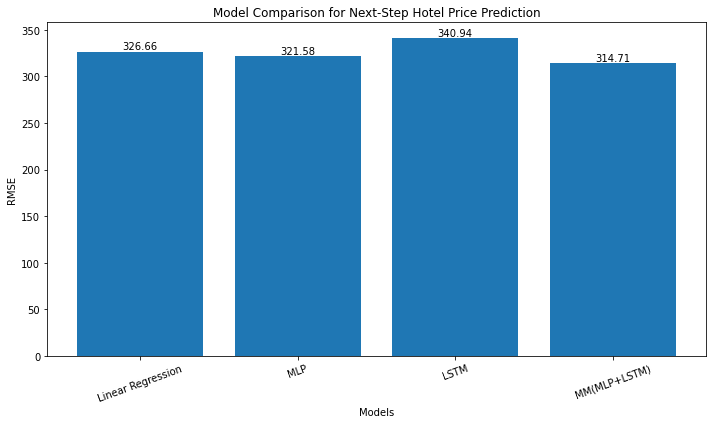

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
bars = plt.bar(results_df["Model"], results_df["RMSE"])

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"{h:.2f}",
        ha="center",
        va="bottom"
    )

plt.xlabel("Models")
plt.ylabel("RMSE")
plt.title("Model Comparison for Next-Step Hotel Price Prediction")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

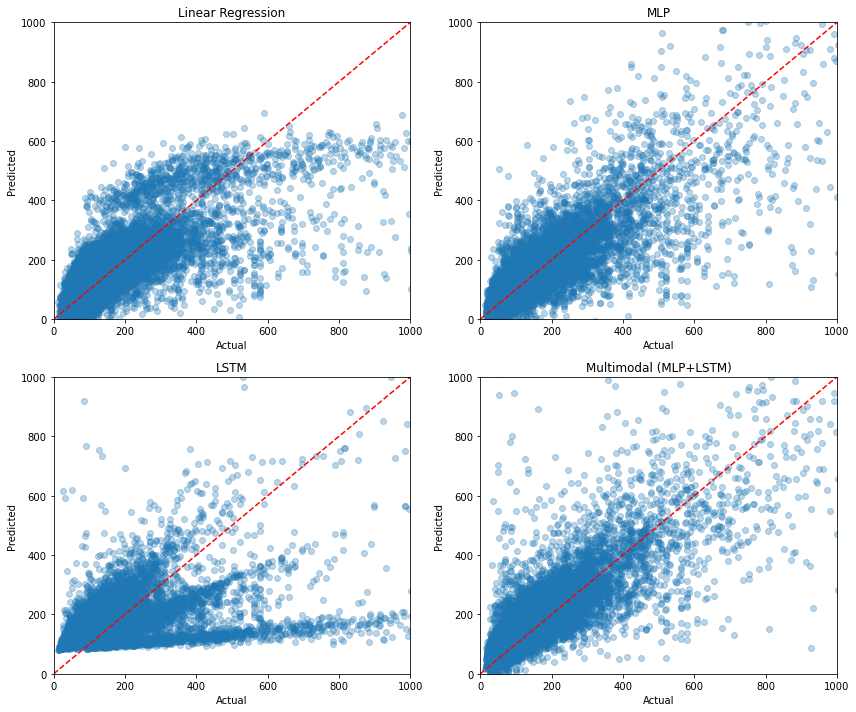

In [95]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

# 1 Linear Regression
plt.subplot(2,2,1)
plt.scatter(y_test_tab, pred_lr, alpha=0.3)
plt.plot([0,1000],[0,1000],'r--')
plt.title("Linear Regression")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.xlim(0,1000)
plt.ylim(0,1000)

# 2 MLP
plt.subplot(2,2,2)
plt.scatter(y_test_tab, pred_mlp, alpha=0.3)
plt.plot([0,1000],[0,1000],'r--')
plt.title("MLP")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.xlim(0,1000)
plt.ylim(0,1000)

# 3 LSTM 这里要用 y_test_real
plt.subplot(2,2,3)
plt.scatter(y_test_real, pred_lstm, alpha=0.3)
plt.plot([0,1000],[0,1000],'r--')
plt.title("LSTM")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.xlim(0,1000)
plt.ylim(0,1000)

# 4 Multimodal
plt.subplot(2,2,4)
plt.scatter(y_test_tab, pred_fusion, alpha=0.3)
plt.plot([0,1000],[0,1000],'r--')
plt.title("Multimodal (MLP+LSTM)")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.xlim(0,1000)
plt.ylim(0,1000)

plt.tight_layout()
plt.show()

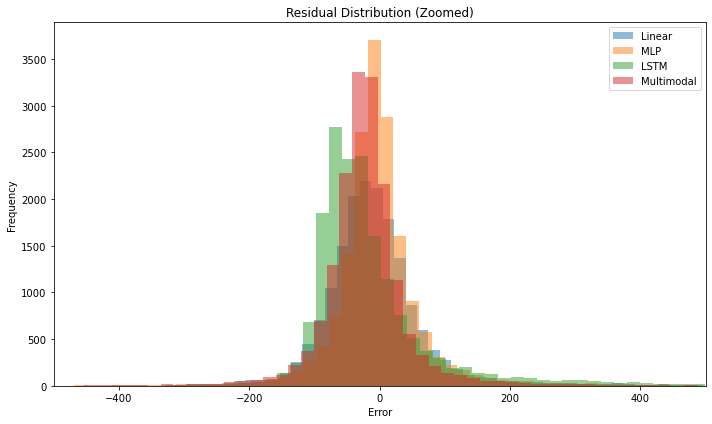

In [96]:
import matplotlib.pyplot as plt
import numpy as np


err_lr = y_test_tab - pred_lr
err_mlp = y_test_tab - pred_mlp
err_lstm = y_test_real - pred_lstm   
err_mm = y_test_tab - pred_fusion

plt.figure(figsize=(10,6))


limit = 500
mask_lr = np.abs(err_lr) < limit
mask_mlp = np.abs(err_mlp) < limit
mask_lstm = np.abs(err_lstm) < limit
mask_mm = np.abs(err_mm) < limit

plt.hist(err_lr[mask_lr], bins=50, alpha=0.5, label="Linear")
plt.hist(err_mlp[mask_mlp], bins=50, alpha=0.5, label="MLP")
plt.hist(err_lstm[mask_lstm], bins=50, alpha=0.5, label="LSTM")
plt.hist(err_mm[mask_mm], bins=50, alpha=0.5, label="Multimodal")

plt.legend()
plt.title("Residual Distribution (Zoomed)")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.xlim(-500, 500)

plt.tight_layout()
plt.show()

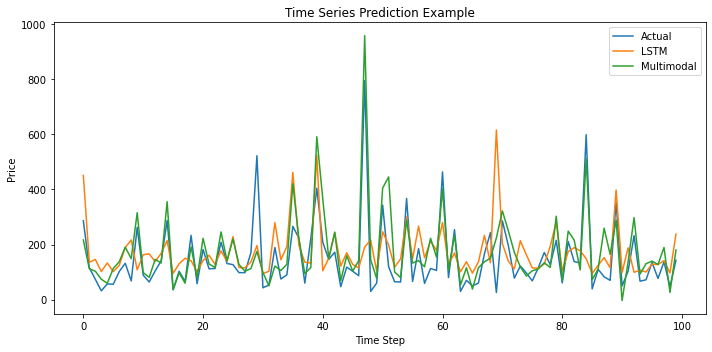

In [97]:
plt.figure(figsize=(10,5))

plt.plot(y_test_real[:100], label="Actual")
plt.plot(pred_lstm[:100], label="LSTM")
plt.plot(pred_fusion[:100], label="Multimodal")

plt.legend()
plt.title("Time Series Prediction Example")
plt.xlabel("Time Step")
plt.ylabel("Price")

plt.tight_layout()
plt.show()